# Week 2: Hidden Anomalies in Observed Data

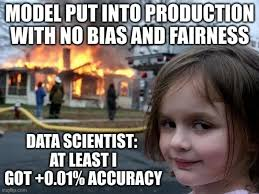

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [ ]:
#%% Load data
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("data/data")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


AGEP: Age (integer from 0 to 99), COW: class of worker (9 classes), SCHL: Educational attainment e.g. grade 5 (24 classes), MAR: Marital status (5 classes), OCCP: Occupation (500+ categories), POBP: Place of birth (200+ categories), RELP: Relationship to householder (18 classes e.g. husband/wife is 1), WKHP: Usual hours worked per week in the past 12 months, SEX: Sex code (1 Male, 2 Female), RAC1P: Race code (9 classes)

In [ ]:
#%% Define attribute limitations as dictionary
attribute_rules = {'AGEP': {'range': range(0,100), 'dtype': "int"}, 
                   'COW': {'range': range(1,10), 'dtype': "int"},
                   'SCHL': {'range': range(1,25), 'dtype': "int"},
                   'MAR': {'range': range(1,6), 'dtype': "int"},
                   'OCCP': {'dtype': "int", 'range': range(0,9760+1)},
                   'POBP': {'dtype': "int", 'range': (0,554+1)},
                   'RELP': {'dtype': "int", 'range': range(0,18)},
                   'WKHP': {'dtype': "int", 'range': range(1,100)},
                   'SEX': {'dtype': "int", 'range': [1,2]},
                   'RAC1P': {'dtype': "int", 'range': range(1,10)},
                   'SEX_group': {'dtype': "str", 'range': ['Male', 'Female']},
                   'RACE_group': {'dtype': "str", 'range': ['White', 'Black', 'American Indian', 'Alaska Native', 'AIAN specified/other', 'Asian', 'Pacific Islander', 'Other race', 'Two or more races']},
                   'SURVEY_BATCH': {'dtype': "str", 'range': ['B04', 'B06', 'B02', 'B08', 'B01', 'B07', 'B05', 'B03']},
                   'income_observed': {'dtype': "int", 'range': [0,1]}
                    }

Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [170]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df):
    n,m = df.shape
    print(f"Dataframe shape: ({n},{m})")
    print("Number of unique values per column:")
    print(df.nunique())
    all_good_flag = True

    if df.drop_duplicates().shape[0] < n:
            print("There are duplicate rows in the dataframe")

    # Checks for missingness:
    cols = list(df.columns)
    for c in cols:
        if c == 'row_id':
            if df[c].duplicated().sum()>0:
                print(f"There are duplicated row id's")
                all_good_flag = False
            continue
        nnull = df[c].isna().sum()
        if nnull >0:
            print(f"Column {c} is missing {nnull} values")
            all_good_flag = False
        rules = attribute_rules[c]
        try:
            df[c] = df[c].astype(rules['dtype'])
        except:
            print(f"Column {c} has the wrong datatype and could not be converted to the true datatype")
            all_good_flag = False

        if 'range'in rules.keys():
            diff_values = set(df[c].unique()) - set(rules['range'])
            if len(diff_values)>0:
                print(f"Column {c} has the following impossible values: {diff_values}")
                all_good_flag = False
        if 'min' in rules.keys() and df[c].min()<rules['min']:
            print(f"Column {c} has an invalid minimum value")
            all_good_flag = False

        if df[c].nunique()>2:
            print(f"Top 3 classes in column {c} are: {df[c].value_counts().head(3)}")
        else:
            print(f"The distribution of {c} is {df[c].value_counts()}")

    if sum(df['SEX']==df['SEX_group'].map({"Male": 1, "Female": 2}))<n:
        print("There is a mistake in the mapping of SEX_group")
        all_good_flag = False

    if sum(df['RAC1P']==df['RACE_group'].map({'White': 1, 'Black': 2, 'American Indian': 3, 'Alaska Native': 4, 'AIAN specified/other': 5, 'Asian': 6, 'Pacific Islander': 7, 'Other race': 8, 'Two or more races':9}))<n:
        print("There is a mistake in the mapping of RACE_group")
        all_good_flag = False

    if all_good_flag:
        print("No missing data, no duplicated rows and no impossible values")

    return df

    
            

In [176]:
train = dataset_summary(train)
validation = dataset_summary(validation)
test_features = dataset_summary(test_features)

Dataframe shape: (18000,15)
Number of unique values per column:
row_id             18000
AGEP                  73
COW                    8
SCHL                  24
MAR                    5
OCCP                 515
POBP                 184
RELP                  18
WKHP                  93
SEX                    2
RAC1P                  9
SEX_group              2
RACE_group             9
SURVEY_BATCH           8
income_observed        2
dtype: int64
Top 3 classes in column AGEP are: AGEP
26    400
50    387
39    386
Name: count, dtype: int64
Top 3 classes in column COW are: COW
1    12285
6     1336
3     1202
Name: count, dtype: int64
Top 3 classes in column SCHL are: SCHL
21    3974
16    3457
19    2876
Name: count, dtype: int64
Top 3 classes in column MAR are: MAR
1    9987
5    5174
3    2026
Name: count, dtype: int64
Top 3 classes in column OCCP are: OCCP
2310    591
440     465
9130    444
Name: count, dtype: int64
Top 3 classes in column POBP are: POBP
48     9493
303    1648
6 

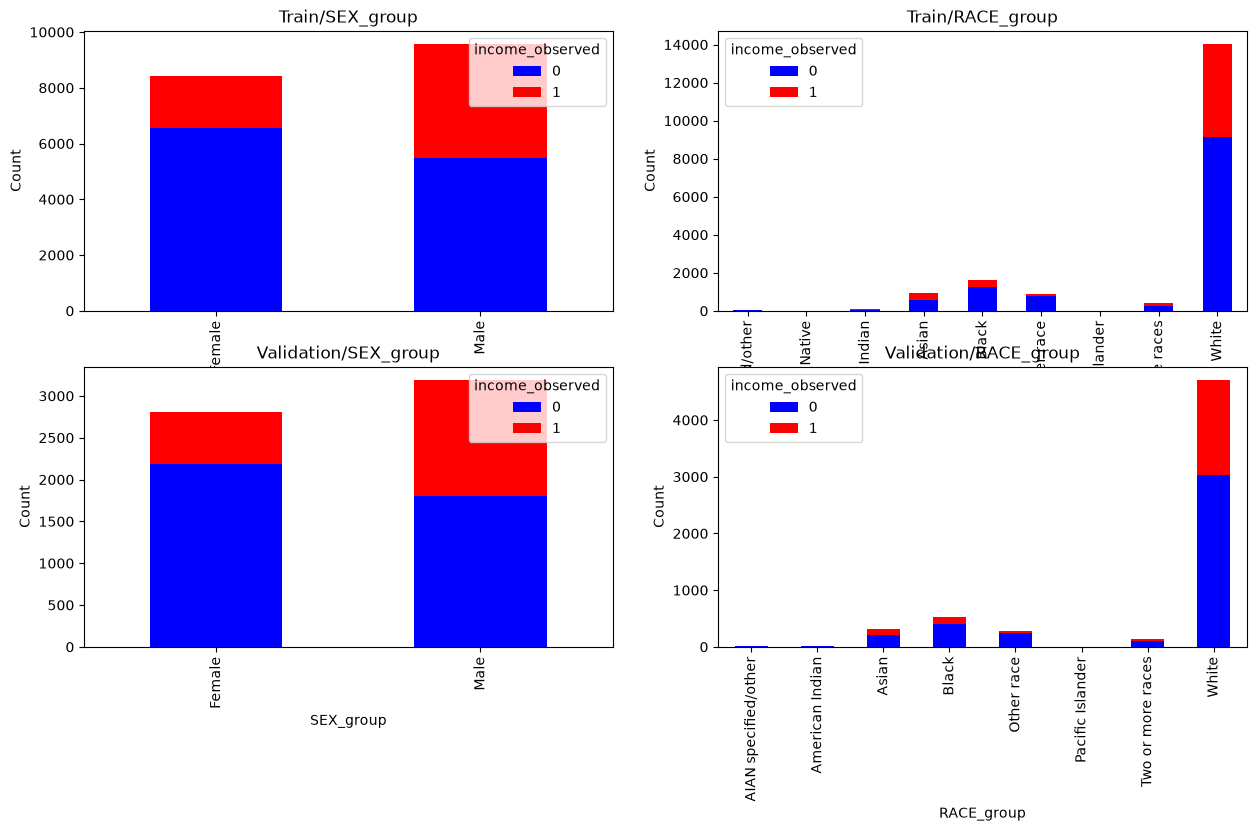

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

counts_train_sex = pd.crosstab(train["SEX_group"], train["income_observed"])
counts_train_sex.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[0,0])
axes[0,0].set_xlabel("SEX_group")
axes[0,0].set_ylabel("Count")
axes[0,0].legend(title="income_observed")
axes[0,0].set_title("Train/SEX_group")

counts_train_race = pd.crosstab(train["RACE_group"], train["income_observed"])
counts_train_race.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[0,1])
axes[0,1].set_xlabel("RACE_group")
axes[0,1].set_ylabel("Count")
axes[0,1].legend(title="income_observed")
axes[0,1].set_title("Train/RACE_group")

counts_validation_sex = pd.crosstab(validation["SEX_group"], validation["income_observed"])
counts_validation_sex.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[1,0])
axes[1,0].set_xlabel("SEX_group")
axes[1,0].set_ylabel("Count")
axes[1,0].legend(title="income_observed")
axes[1,0].set_title("Validation/SEX_group")

counts_validation_race = pd.crosstab(validation["RACE_group"], validation["income_observed"])
counts_validation_race.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[1,1])
axes[1,1].set_xlabel("RACE_group")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(title="income_observed")
axes[1,1].set_title("Validation/RACE_group")

plt.show()

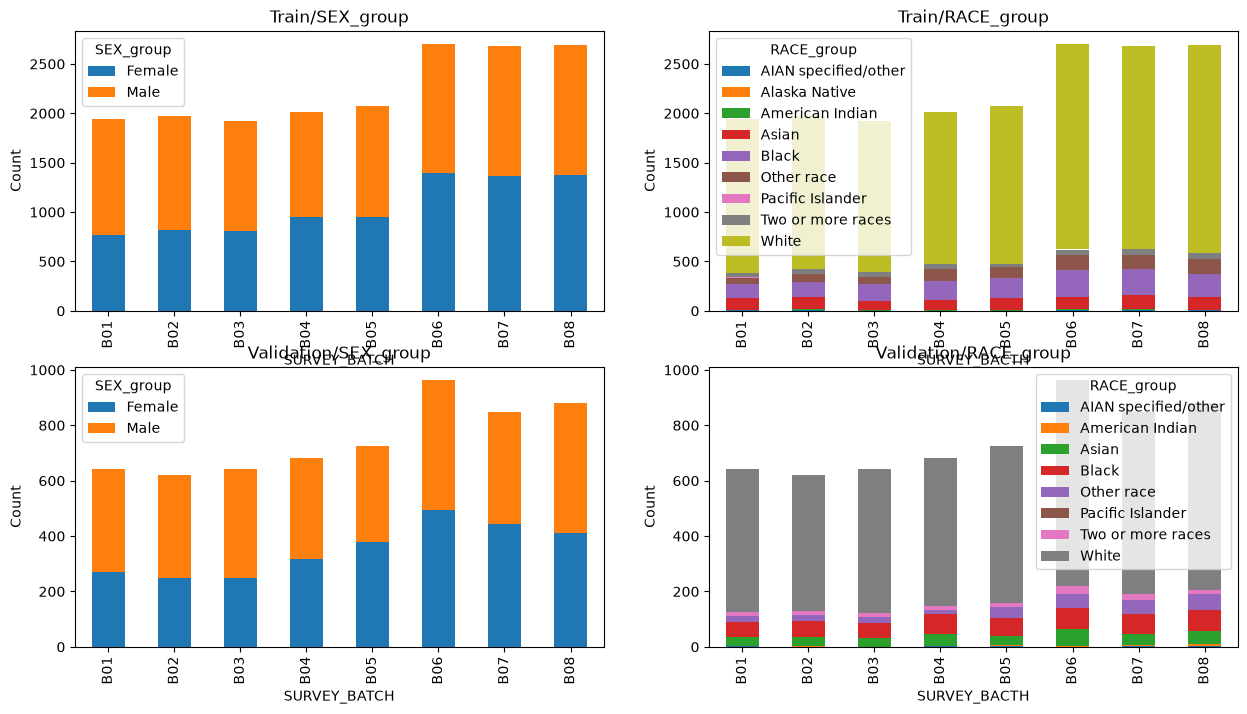

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

counts_train_sex = pd.crosstab(train["SURVEY_BATCH"], train["SEX_group"])
counts_train_sex.plot(kind="bar", stacked=True, ax = axes[0,0])
axes[0,0].set_xlabel("SURVEY_BATCH")
axes[0,0].set_ylabel("Count")
axes[0,0].legend(title="SEX_group")
axes[0,0].set_title("Train/SEX_group")

counts_train_race = pd.crosstab(train["SURVEY_BATCH"], train["RACE_group"])
counts_train_race.plot(kind="bar", stacked=True,  ax = axes[0,1])
axes[0,1].set_xlabel("SURVEY_BACTH")
axes[0,1].set_ylabel("Count")
axes[0,1].legend(title="RACE_group")
axes[0,1].set_title("Train/RACE_group")

counts_validation_sex = pd.crosstab(validation["SURVEY_BATCH"], validation["SEX_group"])
counts_validation_sex.plot(kind="bar", stacked=True,  ax = axes[1,0])
axes[1,0].set_xlabel("SURVEY_BATCH")
axes[1,0].set_ylabel("Count")
axes[1,0].legend(title="SEX_group")
axes[1,0].set_title("Validation/SEX_group")

counts_validation_race = pd.crosstab(validation["SURVEY_BATCH"], validation["RACE_group"])
counts_validation_race.plot(kind="bar", stacked=True,  ax = axes[1,1])
axes[1,1].set_xlabel("SURVEY_BACTH")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(title="RACE_group")
axes[1,1].set_title("Validation/RACE_group")

plt.show()

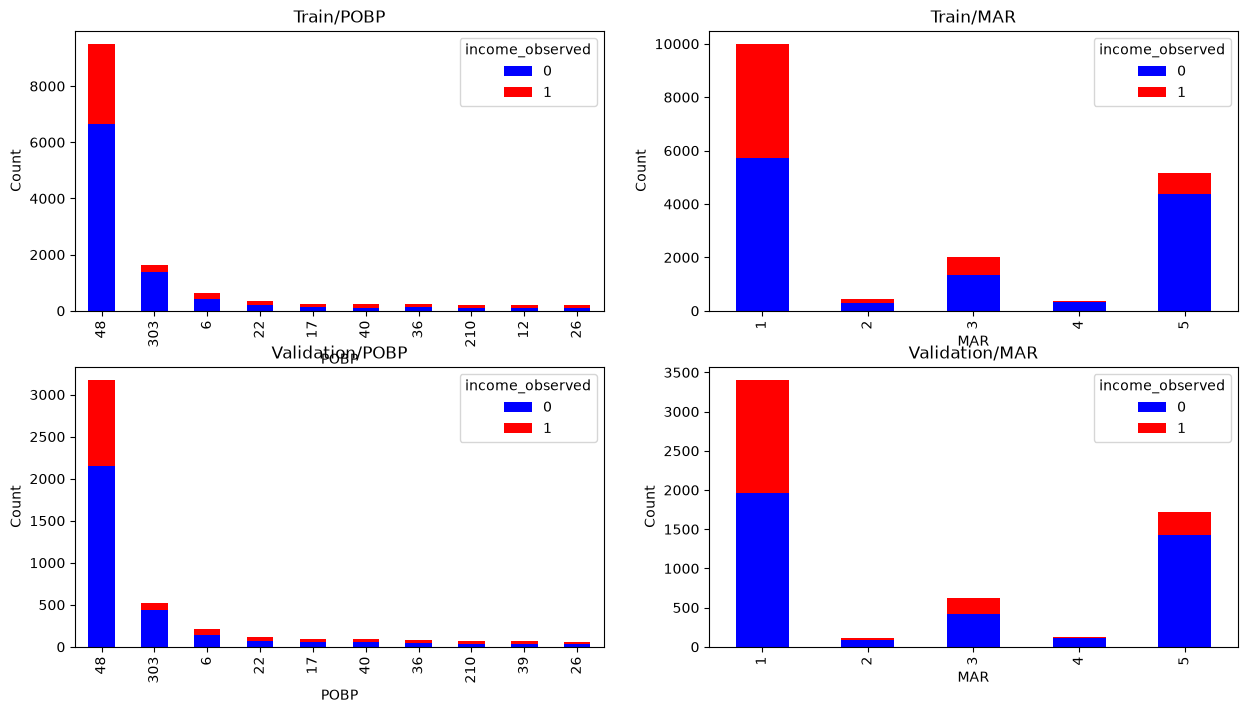

In [212]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

top_pobp = train["POBP"].value_counts().nlargest(10).index
counts_train_pobp = pd.crosstab(train["POBP"],train["income_observed"]).loc[top_pobp]
counts_train_pobp.plot(kind="bar",stacked=True, color=["blue", "red"], ax=axes[0,0])
axes[0,0].set_xlabel("POBP")
axes[0,0].set_ylabel("Count")
axes[0,0].legend(title="income_observed")
axes[0,0].set_title("Train/POBP")

counts_train_mar = pd.crosstab(train["MAR"], train["income_observed"])
counts_train_mar.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[0,1])
axes[0,1].set_xlabel("MAR")
axes[0,1].set_ylabel("Count")
axes[0,1].legend(title="income_observed")
axes[0,1].set_title("Train/MAR")

top_pobp = validation["POBP"].value_counts().nlargest(10).index
counts_validation_pobp = pd.crosstab(validation["POBP"],validation["income_observed"]).loc[top_pobp]
counts_validation_pobp.plot(kind="bar",stacked=True, color=["blue", "red"], ax=axes[1,0])
axes[1,0].set_xlabel("POBP")
axes[1,0].set_ylabel("Count")
axes[1,0].legend(title="income_observed")
axes[1,0].set_title("Validation/POBP")

counts_validation_mar = pd.crosstab(validation["MAR"], validation["income_observed"])
counts_validation_mar.plot(kind="bar", stacked=True, color=["blue", "red"], ax = axes[1,1])
axes[1,1].set_xlabel("MAR")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(title="income_observed")
axes[1,1].set_title("Validation/MAR")

plt.show()

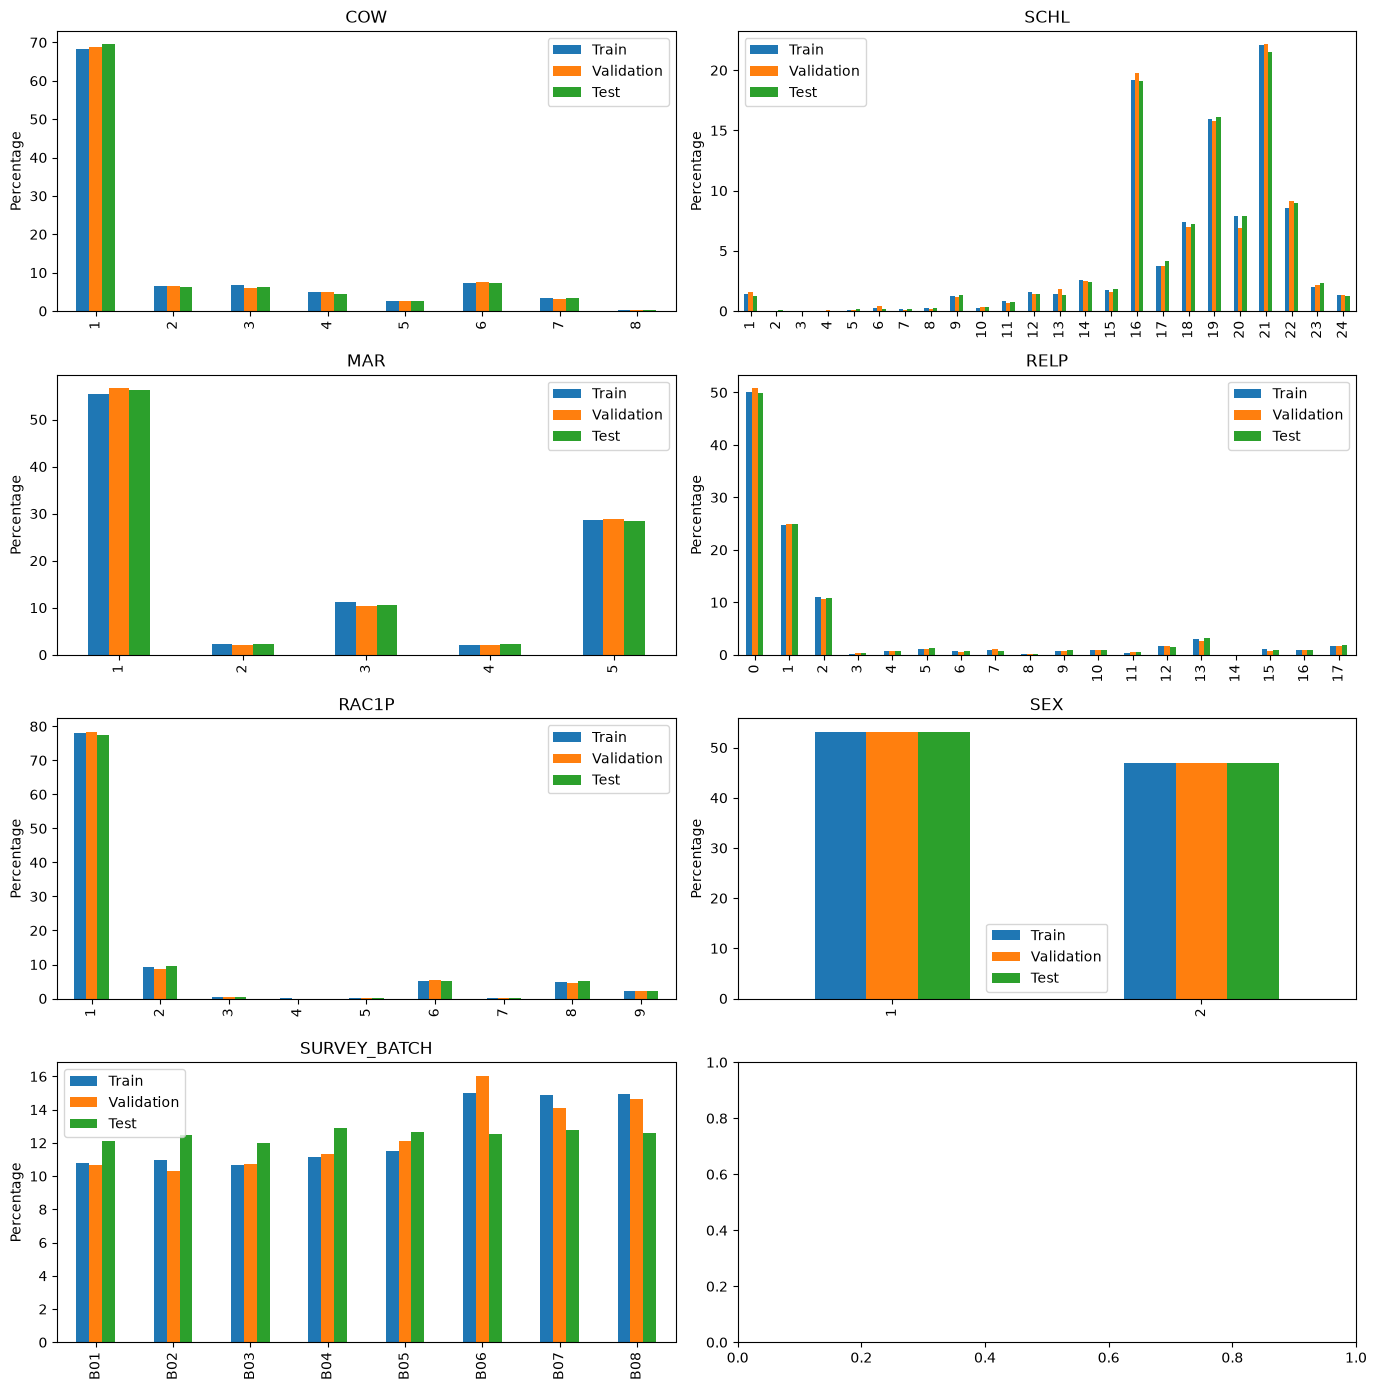

In [185]:
# TODO: compare train, validation, and test feature distributions.
# Include categorical as well as numeric variables.

features = ['COW', 'SCHL', 'MAR', 'RELP','RAC1P', 'SEX', 'SURVEY_BATCH']

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, feature in zip(axes, features):

    comparison = pd.DataFrame({
        "Train": train[feature].value_counts(normalize=True),
        "Validation": validation[feature].value_counts(normalize=True),
        "Test": test_features[feature].value_counts(normalize=True),
    }).fillna(0) * 100

    comparison.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Percentage")
    ax.legend()


plt.tight_layout()
plt.show()

In [188]:
for column in ["OCCP", "POBP"]:
    print(column, "Train:", train[column].max(), "Validation:", validation[column].max(), "Test:", test_features[column].max())

OCCP Train: 9830 Validation: 9830 Test: 9830
POBP Train: 554 Validation: 501 Test: 554


In [194]:
def compare_binned(train, validation, test, column, bins, labels, ax, xlabel):
    train_binned = pd.cut(
        train[column],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    validation_binned = pd.cut(
        validation[column],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    test_binned = pd.cut(
        test[column],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    comparison = pd.DataFrame({
        "Train": train_binned.value_counts(normalize=True),
        "Validation": validation_binned.value_counts(normalize=True),
        "Test": test_binned.value_counts(normalize=True)
    }).fillna(0) * 100

    comparison = comparison.reindex(labels)

    comparison.plot(
        kind="bar",
        ax=ax
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Percentage")
    ax.tick_params(axis="x", rotation=45)

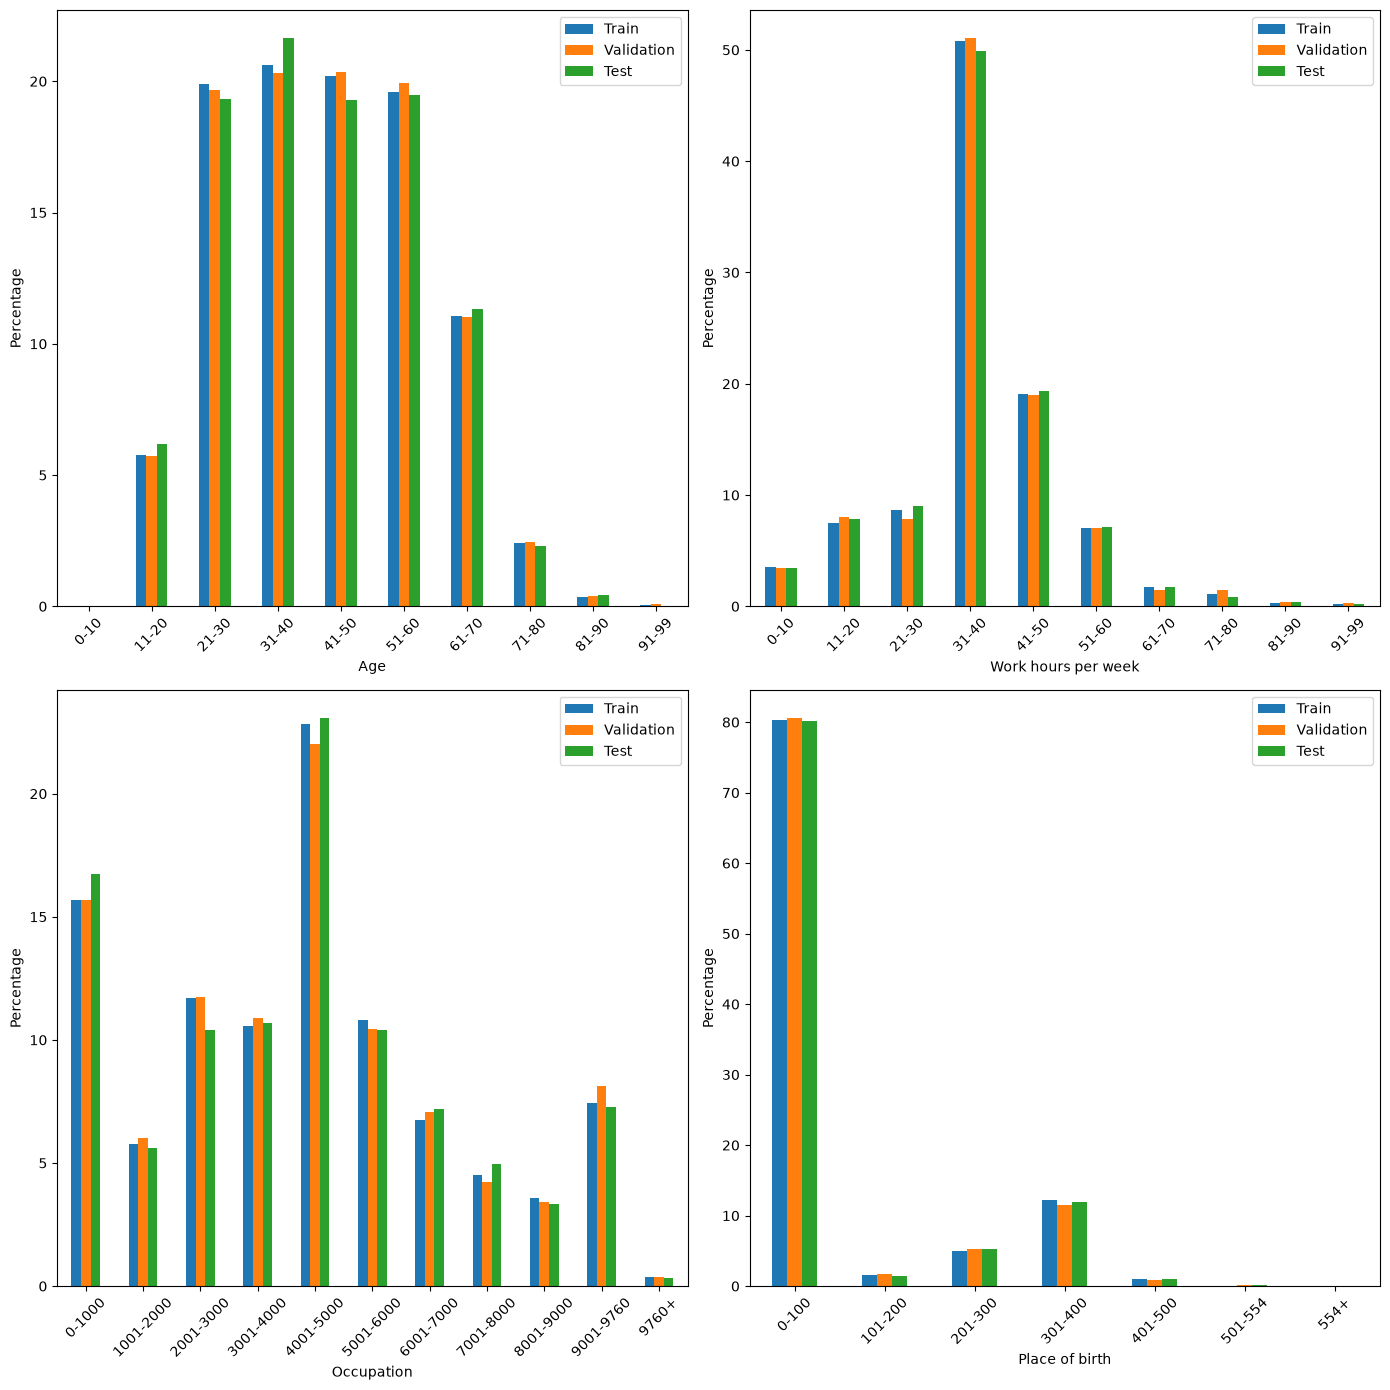

In [195]:
features_to_bin = ['AGEP', 'OCCP', 'POBP', 'WKHP']

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# AGEP
compare_binned(
    train, validation, test_features, "AGEP",
    [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    ["0-10", "11-20","21-30","31-40","41-50","51-60","61-70","71-80","81-90","91-99"],
    axes[0, 0], "Age"
)

#WKHP
compare_binned(
    train, validation, test_features, "WKHP",
    [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    ["0-10", "11-20","21-30","31-40","41-50","51-60","61-70","71-80","81-90","91-99"],
    axes[0, 1], "Work hours per week"
)

# OCCP
compare_binned(
    train, validation, test_features, "OCCP",
    [0, 1000, 2000, 3000, 4000, 5000, 6000,7000,8000,9000,9760,float('inf')],
    ["0-1000", "1001-2000","2001-3000","3001-4000","4001-5000","5001-6000", "6001-7000", "7001-8000", "8001-9000", "9001-9760", "9760+"],
    axes[1, 0], "Occupation"
)

# POBP
compare_binned(
    train, validation, test_features, "POBP",
    [0, 100, 200, 300, 400, 500, 554, float('inf')],
    ["0-100", "101-200","201-300","301-400","401-500", "501-554", "554+"],
    axes[1, 1], "Place of birth"
)

plt.tight_layout()
plt.show()

In [209]:
cols = ["SEX", "COW", "SCHL", "RAC1P", "MAR"]

# Frequency of each value within each column
freq = {
    col: train[col].value_counts(normalize=True) for col in cols}

# Score each row
a = train.apply(lambda row: sum(freq[col].get(row[col], 0) for col in cols), axis=1)

# Most typical rows
most_typical = a.nlargest(3)
print(train.loc[most_typical.index])

     row_id  AGEP  COW  SCHL  MAR  OCCP  POBP  RELP  WKHP  SEX  RAC1P  \
2         2    29    1    21    1  6800     6     0    48    1      1   
16       16    42    1    21    1   845    17     0    40    1      1   
166     166    49    1    21    1  4760   364     1    60    1      1   

    SEX_group RACE_group SURVEY_BATCH  income_observed  
2        Male      White          B02                1  
16       Male      White          B05                1  
166      Male      White          B04                1  


Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [248]:
most_common_places = {48: "Texas", 303: "Mexico", 6: "California", 22: "Louisiana", 17: "Illinois", 40: "Oklahoma", 
                      36: "New York", 210: "India", 12: "Florida", 26: "Michigan"}

In [233]:
train['place_of_birth'] = train['POBP'].map({**{a: a for a in list(counts_train_pobp.index)},**{a: 'Other' for a in train.POBP if a not in counts_train_pobp.index}})
validation['place_of_birth'] = validation['POBP'].map({**{a: a for a in list(counts_train_pobp.index)},**{a: 'Other' for a in validation.POBP if a not in counts_train_pobp.index}})

In [234]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = ["SEX_group", "RACE_group", "place_of_birth", "MAR"]

# TODO: choose features and justify exclusions.
FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "OCCP", "RELP", "WKHP"]

# TODO: write a model factory that handles numeric and categorical columns.
NUMERIC = ["AGEP", "WKHP"]
def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in FEATURE_COLUMNS if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
model = make_model(train[FEATURE_COLUMNS])
model.fit(train[FEATURE_COLUMNS], train["income_observed"])
val_score = model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
val_pred = (val_score >= .5).astype(int)

logistic_accuracy = accuracy_score(validation["income_observed"], val_pred)

baseline_pred = (validation['WKHP']> 40).astype(int)
baseline_accuracy = accuracy_score(validation["income_observed"], baseline_pred)

print(f"Logistic regression accuracy: {logistic_accuracy:.3f}")
print(f"WKHP baseline accuracy:       {baseline_accuracy:.3f}")


Logistic regression accuracy: 0.780
WKHP baseline accuracy:       0.703


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [216]:
# From last week:
def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp/(tn+fp) if (tn+fp)>0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fn) if (tn+fn)>0 else np.nan

In [ ]:
for s in SENSITIVE:
    group_counts = pd.crosstab(
    validation[s],
    validation["income_observed"]
    )
    display(group_counts)

income_observed,0,1
SEX_group,,
Female,2188,624
Male,1806,1382


income_observed,0,1
RACE_group,,
AIAN specified/other,13,2
American Indian,16,4
Asian,201,117
Black,402,124
Other race,239,42
Pacific Islander,2,1
Two or more races,95,39
White,3026,1677


income_observed,0,1
place_of_birth,,
6,143,64
12,32,19
17,58,37
22,70,51
26,32,26
36,46,38
40,52,36
48,2156,1016
210,32,38


income_observed,0,1
MAR,,
1,1956,1445
2,82,37
3,424,201
4,109,20
5,1423,303


In [250]:
from fairlearn.metrics import MetricFrame, selection_rate, count, demographic_parity_difference, demographic_parity_ratio, equalized_odds_difference, equalized_odds_ratio
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# TODO: implement robust metric functions.
# TODO: construct MetricFrame for SEX_group and at least one intersection.
def confusion_matrix_binary(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
    "confusion_matrix": confusion_matrix_binary
}

mf = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['SEX_group'])
mf_race = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['RACE_group'])
mf_pobp = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['place_of_birth'])
mf_mar = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=val_pred, sensitive_features=validation['MAR'])

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
display(mf_race.by_group)
display(mf_pobp.by_group)
display(mf_mar.by_group)

for s in SENSITIVE:
    fairness_summary = pd.Series({
        "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], val_pred, sensitive_features=validation[s]), 
        "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], val_pred, sensitive_features=validation[s]),
        "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], val_pred, sensitive_features=validation[s]),
        "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], val_pred, sensitive_features=validation[s]),
    })
    print(s)
    display(fairness_summary)

Overall threshold metrics


n                                          6000
accuracy                               0.780167
balanced_accuracy                      0.737983
selection_rate                         0.293833
TPR_recall                             0.610668
FPR                                    0.134702
PPV_precision                          0.694838
NPV                                    0.815671
TNR                                    0.865298
confusion_matrix     [[3456, 538], [781, 1225]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
SEX_group,,,,,,,,,,
Female,2812,0.788762,0.691858,0.219061,0.517628,0.133912,0.524351,0.862933,0.866088,"[[1895, 293], [301, 323]]"
Male,3188,0.772585,0.758509,0.359787,0.652677,0.135659,0.786399,0.764821,0.864341,"[[1561, 245], [480, 902]]"


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
RACE_group,,,,,,,,,,
AIAN specified/other,15,1.000000,1.000000,0.133333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[13, 0], [0, 2]]"
American Indian,20,0.900000,0.843750,0.200000,0.750000,0.062500,0.750000,0.937500,0.937500,"[[15, 1], [1, 3]]"
Asian,318,0.748428,0.758132,0.468553,0.794872,0.278607,0.624161,0.857988,0.721393,"[[145, 56], [24, 93]]"
Black,526,0.779468,0.649374,0.174905,0.403226,0.104478,0.543478,0.829493,0.895522,"[[360, 42], [74, 50]]"
Other race,281,0.857651,0.661187,0.106762,0.380952,0.058577,0.533333,0.896414,0.941423,"[[225, 14], [26, 16]]"
Pacific Islander,3,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[2, 0], [0, 1]]"
Two or more races,134,0.776119,0.698516,0.231343,0.512821,0.115789,0.645161,0.815534,0.884211,"[[84, 11], [19, 20]]"
White,4703,0.776526,0.741670,0.309164,0.620155,0.136814,0.715268,0.803940,0.863186,"[[2612, 414], [637, 1040]]"


...

demographic_parity_difference    0.361792
demographic_parity_ratio         0.227854
equalized_odds_difference        0.619048
equalized_odds_ratio             0.000000
dtype: float64

place_of_birth


demographic_parity_difference    0.557087
demographic_parity_ratio         0.170295
equalized_odds_difference        0.422638
equalized_odds_ratio             0.116133
dtype: float64

MAR


demographic_parity_difference    0.286170
demographic_parity_ratio         0.260438
equalized_odds_difference        0.360208
equalized_odds_ratio             0.347002
dtype: float64

TPR: TP/(TP+FN) 

FP/(FP+TN) (the proportion of actual negative cases that a test or model incorrectly labels as positive)

### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

Note: The Brier score measures how accurate a model's predicted probabilities are.

,n,mean_predicted,observed_rate,gap
bin,,,,
"(-0.001, 0.1]",1725,0.041629,0.041739,0.000110
"(0.1, 0.2]",883,0.147447,0.156285,0.008839
"(0.2, 0.3]",600,0.249150,0.248333,-0.000817
"(0.3, 0.4]",522,0.347390,0.354406,0.007016
"(0.4, 0.5]",507,0.449478,0.467456,0.017978
"(0.5, 0.6]",438,0.550283,0.545662,-0.004621
"(0.6, 0.7]",431,0.648781,0.603248,-0.045533
"(0.7, 0.8]",429,0.748549,0.734266,-0.014284
"(0.8, 0.9]",345,0.847730,0.857971,0.010241


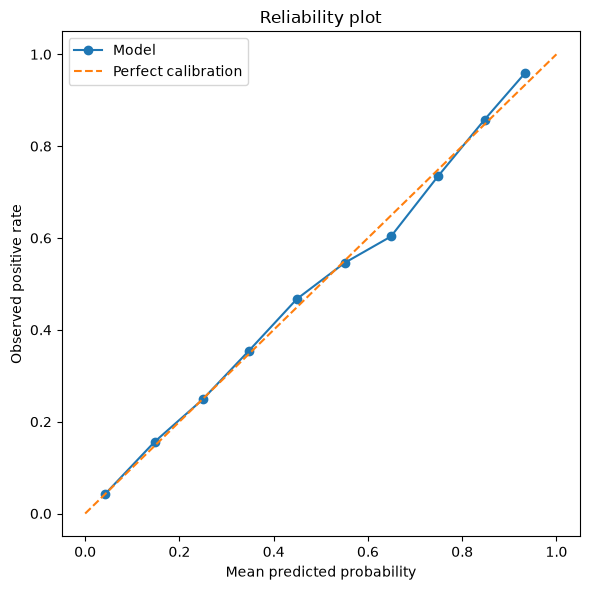

ECE: 0.0093


In [255]:
# TODO: implement calibration tables, reliability plots, and a numerical summary such as ECE.
# State how you handle small bins and why your binning choice is defensible.

# Calibration table (code from ChatGPT)
n_bins = 10

calibration = pd.DataFrame({"y_true": validation["income_observed"].to_numpy(), "y_prob": val_score})

calibration["bin"] = pd.cut(calibration["y_prob"], bins=np.linspace(0, 1, n_bins + 1), include_lowest=True)

calibration_table = (
    calibration
    .groupby("bin", observed=False)
    .agg(
        n=("y_true", "size"),
        mean_predicted=("y_prob", "mean"),
        observed_rate=("y_true", "mean")
    )
)

calibration_table["gap"] = (
    calibration_table["observed_rate"]
    - calibration_table["mean_predicted"]
)

display(calibration_table)

# Reliability plot (code from ChatGPT)
plt.figure(figsize=(6, 6))

plt.plot(
    calibration_table["mean_predicted"],
    calibration_table["observed_rate"],
    marker="o",
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability plot")
plt.legend()
plt.tight_layout()
plt.show()

# ECE (code from ChatGPT)
ece = (
    (
        calibration_table["n"]
        / calibration_table["n"].sum()
    )
    * calibration_table["gap"].abs()
).sum()

print(f"ECE: {ece:.4f}")

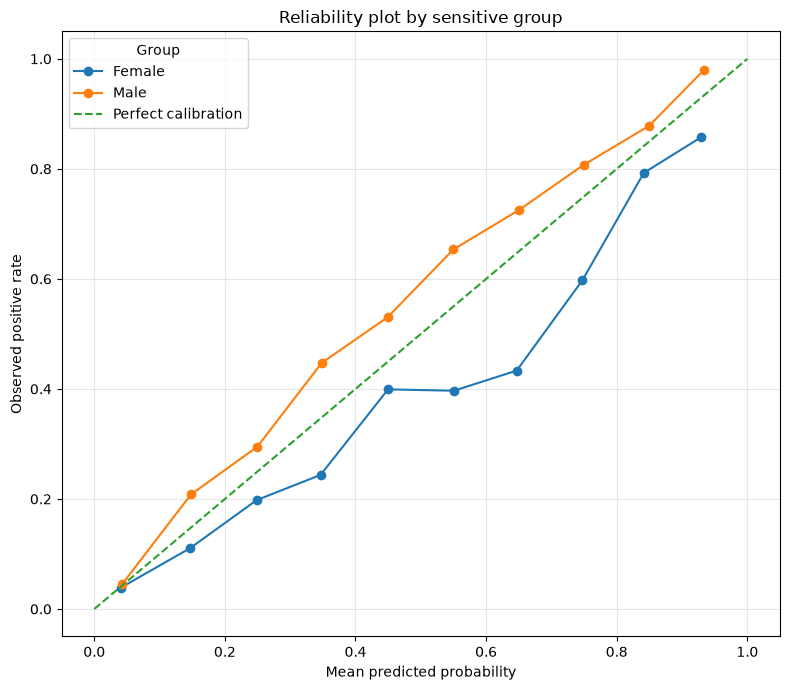

In [258]:
# Calibration by group (code from ChatGPT)

calibration_data = pd.DataFrame({
    "y_true": validation["income_observed"].to_numpy(),
    "y_prob": val_score,
    "group": validation["SEX_group"].to_numpy()
})

n_bins = 10

plt.figure(figsize=(8, 7))

for group, group_df in calibration_data.groupby("group"):
    group_df = group_df.copy()

    group_df["bin"] = pd.cut(
        group_df["y_prob"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True
    )

    calibration_group = (
        group_df
        .groupby("bin", observed=False)
        .agg(
            n=("y_true", "size"),
            mean_predicted=("y_prob", "mean"),
            observed_rate=("y_true", "mean")
        )
    )

    # Only plot bins containing observations
    calibration_group = calibration_group[calibration_group["n"] > 0]

    plt.plot(
        calibration_group["mean_predicted"],
        calibration_group["observed_rate"],
        marker="o",
        label=str(group)
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability plot by sensitive group")
plt.legend(title=SENSITIVE if isinstance(SENSITIVE, str) else "Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [260]:
from sklearn.metrics import brier_score_loss

brier_summary = (
    validation
    .assign(predicted_probability=val_score)
    .groupby("SEX_group")
    .apply(
        lambda df: pd.Series({
            "n": len(df),
            "brier_score": brier_score_loss(
                df["income_observed"],
                df["predicted_probability"]
            )
        }),
        include_groups=False
    )
)

display(brier_summary)

,n,brier_score
SEX_group,,
Female,2812.0,0.138291
Male,3188.0,0.154465


In [262]:
# TODO: Mitigation 
# Let's do equalized odss over SEX_group
from fairlearn.postprocessing import ThresholdOptimizer

sensitive = validation["SEX_group"]

postprocessor = ThresholdOptimizer(
    estimator=model,
    constraints="equalized_odds",
    objective="accuracy_score",
    predict_method="predict_proba",
    prefit=True
)

postprocessor.fit(
    validation[FEATURE_COLUMNS],
    validation["income_observed"],
    sensitive_features=sensitive
)

eo_pred = postprocessor.predict(
    validation[FEATURE_COLUMNS],
    sensitive_features=sensitive
)

In [264]:
eo_mf = MetricFrame(metrics=metrics, y_true=validation['income_observed'], y_pred=eo_pred, sensitive_features=validation['SEX_group'])

print("Overall threshold metrics")
print("Before post-processing")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], val_pred, sensitive_features=validation["SEX_group"]), 
    "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], val_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], val_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], val_pred, sensitive_features=validation["SEX_group"]),
})
display(fairness_summary)

print()
print("After Equalized Odds post-processing")
display(pd.Series(eo_mf.overall))
print("By group")
display(eo_mf.by_group)

eo_fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(validation['income_observed'], eo_pred, sensitive_features=validation["SEX_group"]), 
    "demographic_parity_ratio": demographic_parity_ratio(validation['income_observed'], eo_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_difference": equalized_odds_difference(validation['income_observed'], eo_pred, sensitive_features=validation["SEX_group"]),
    "equalized_odds_ratio": equalized_odds_ratio(validation['income_observed'], eo_pred, sensitive_features=validation["SEX_group"]),
})
display(fairness_summary)

Overall threshold metrics
Before post-processing


n                                          6000
accuracy                               0.780167
balanced_accuracy                      0.737983
selection_rate                         0.293833
TPR_recall                             0.610668
FPR                                    0.134702
PPV_precision                          0.694838
NPV                                    0.815671
TNR                                    0.865298
confusion_matrix     [[3456, 538], [781, 1225]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
SEX_group,,,,,,,,,,
Female,2812,0.788762,0.691858,0.219061,0.517628,0.133912,0.524351,0.862933,0.866088,"[[1895, 293], [301, 323]]"
Male,3188,0.772585,0.758509,0.359787,0.652677,0.135659,0.786399,0.764821,0.864341,"[[1561, 245], [480, 902]]"


demographic_parity_difference    0.140726
demographic_parity_ratio         0.608864
equalized_odds_difference        0.135049
equalized_odds_ratio             0.793084
dtype: float64


After Equalized Odds post-processing


n                                          6000
accuracy                                  0.758
balanced_accuracy                      0.726296
selection_rate                         0.329333
TPR_recall                             0.630608
FPR                                    0.178017
PPV_precision                          0.640182
NPV                                    0.815855
TNR                                    0.821983
confusion_matrix     [[3283, 711], [741, 1265]]
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix
SEX_group,,,,,,,,,,
Female,2812,0.781294,0.727725,0.277027,0.631410,0.175960,0.505777,0.886867,0.824040,"[[1803, 385], [230, 394]]"
Male,3188,0.737453,0.724868,0.375471,0.630246,0.180509,0.727652,0.743345,0.819491,"[[1480, 326], [511, 871]]"


demographic_parity_difference    0.140726
demographic_parity_ratio         0.608864
equalized_odds_difference        0.135049
equalized_odds_ratio             0.793084
dtype: float64

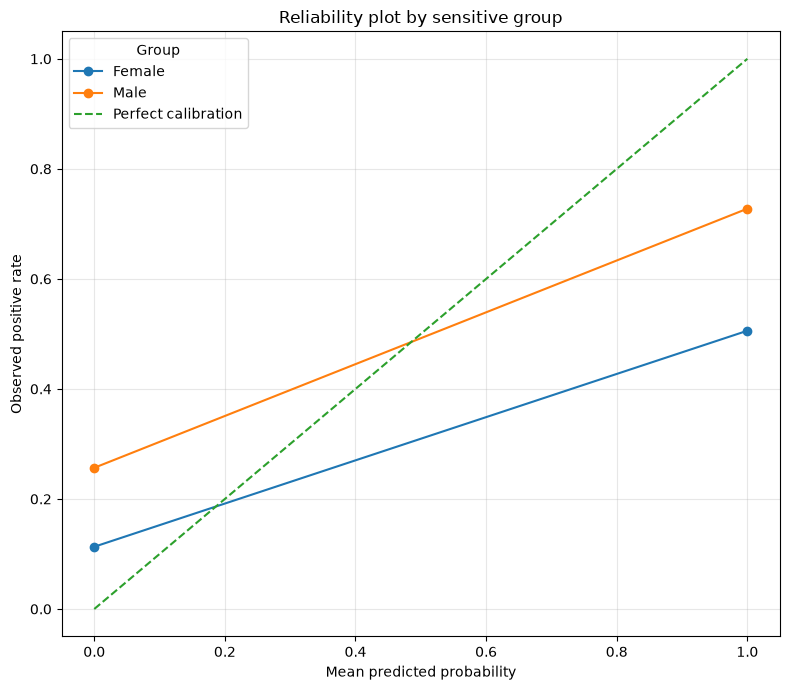

In [265]:
# Calibration by group (code from ChatGPT)

calibration_data = pd.DataFrame({
    "y_true": validation["income_observed"].to_numpy(),
    "y_prob": eo_pred,
    "group": validation["SEX_group"].to_numpy()
})

n_bins = 10

plt.figure(figsize=(8, 7))

for group, group_df in calibration_data.groupby("group"):
    group_df = group_df.copy()

    group_df["bin"] = pd.cut(
        group_df["y_prob"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True
    )

    calibration_group = (
        group_df
        .groupby("bin", observed=False)
        .agg(
            n=("y_true", "size"),
            mean_predicted=("y_prob", "mean"),
            observed_rate=("y_true", "mean")
        )
    )

    # Only plot bins containing observations
    calibration_group = calibration_group[calibration_group["n"] > 0]

    plt.plot(
        calibration_group["mean_predicted"],
        calibration_group["observed_rate"],
        marker="o",
        label=str(group)
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability plot by sensitive group")
plt.legend(title=SENSITIVE if isinstance(SENSITIVE, str) else "Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

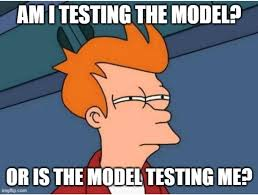

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
